# Stage 12 — Slope experiment

**Question:** should slope be part of the vulnerability index?

Published karst indices that include slope or runoff terms (for example COP and EPIK) do not agree on its direction, because slope pulls two ways:
- **Steeper ground delivers more surface water to sinkholes and sinking streams** (runoff concentrates), which would raise vulnerability.
- **Steeper ground infiltrates less where it falls** (runoff leaves), which would lower it.

Slope also overlaps with connectivity, which already captures how directly surface water reaches the karst. So slope is tested here as a sensitivity variant, not added to the frozen index.

**Method:** slope in degrees from the DEM, scaled to 0-1 by a fixed 30 degree reference (steeper than that counts as 1), and applied as a 0.5-1 multiplier on the frozen risk, the same way the rainfall experiment in Stage 9 works. Both directions are run. Results are reported for the Mole Creek karst only, then statewide at 100 m.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, aggregate_pressure_by_system,
                   rasterize_max, in_mole_creek_focus, mole_creek_focus_mask)

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

SLOPE_REF_DEG = 30.0

def slope_degrees(dem, nodata, cell_size):
    z = np.where(dem == nodata, np.nan, dem.astype(float))
    dzdy, dzdx = np.gradient(z, cell_size)
    return np.degrees(np.arctan(np.hypot(dzdx, dzdy)))

def slope_factors(slope_deg):
    s = np.clip(slope_deg / SLOPE_REF_DEG, 0, 1)
    return {"steeper = higher risk": 0.5 + 0.5 * s,
            "steeper = lower risk": 1.0 - 0.5 * s}

def corr_both(a, b, valid_mask):
    m1 = valid_mask & ~np.isnan(a) & ~np.isnan(b)
    m2 = m1 & ((a > 0) | (b > 0))
    return np.corrcoef(a[m1], b[m1])[0, 1], np.corrcoef(a[m2], b[m2])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

## 12.1 Mole Creek (25 m)

In [2]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure = src.read(1).astype(float); pressure_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape
    cell = abs(src.transform.a)

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]

intrinsic = (intensity / 4.0) * (connectivity / 3.0)
baseline = np.where(valid, intrinsic * aggregate_pressure_by_system(karst_mc, pressure, transform, pressure_nodata) / 3.0, np.nan)

slope = slope_degrees(dem, dem_nodata, cell)
on_karst = slope[valid & ~np.isnan(slope)]
off_karst = slope[(dem != dem_nodata) & ~focus & ~np.isnan(slope)]
print(f"Slope (degrees) on the Mole Creek karst: median {np.median(on_karst):.1f}, 90th percentile {np.percentile(on_karst, 90):.1f}, max {on_karst.max():.1f}")
print(f"Slope elsewhere in the buffer:           median {np.median(off_karst):.1f}, 90th percentile {np.percentile(off_karst, 90):.1f}")

m = valid & ~np.isnan(slope)
print(f"\nOn the karst, correlation of slope with intrinsic vulnerability: r = {np.corrcoef(slope[m], intrinsic[m])[0,1]:.3f}")
print(f"On the karst, correlation of slope with baseline risk:           r = {np.corrcoef(slope[m], baseline[m])[0,1]:.3f}")

# Does the 25 m vs 100 m DEM matter for slope? Block-average to 100 m, compute slope, repeat back to 25 m.
r4, c4 = (shape[0] // 4) * 4, (shape[1] // 4) * 4
z = np.where(dem == dem_nodata, np.nan, dem.astype(float))[:r4, :c4]
z100 = np.nanmean(z.reshape(r4 // 4, 4, c4 // 4, 4), axis=(1, 3))
s100 = np.kron(slope_degrees(np.nan_to_num(z100, nan=-9999), -9999, 4 * cell), np.ones((4, 4)))
v4 = valid[:r4, :c4] & ~np.isnan(s100) & ~np.isnan(slope[:r4, :c4])
print(f"\nMean slope on the karst: {slope[:r4, :c4][v4].mean():.1f} deg from the 25 m DEM, {s100[v4].mean():.1f} deg from a 100 m DEM")

Slope (degrees) on the Mole Creek karst: median 1.9, 90th percentile 14.2, max 57.1
Slope elsewhere in the buffer:           median 8.6, 90th percentile 26.2

On the karst, correlation of slope with intrinsic vulnerability: r = 0.418
On the karst, correlation of slope with baseline risk:           r = 0.436

Mean slope on the karst: 4.9 deg from the 25 m DEM, 4.3 deg from a 100 m DEM


/var/folders/8l/2f4_sjbs057dtvrflrlb5sj40000gn/T/ipykernel_13829/1322026903.py:33: RuntimeWarning: Mean of empty slice
  z100 = np.nanmean(z.reshape(r4 // 4, 4, c4 // 4, 4), axis=(1, 3))


In [3]:
results_mc = {}
print("Variant against the frozen baseline, on the Mole Creek karst (all-cells r | nonzero r | mean risk):")
print(f"  baseline: mean risk {np.nanmean(baseline[valid]):.4f}")
for label, factor in slope_factors(slope).items():
    risk = baseline * factor
    results_mc[label] = risk
    r_all, r_nz = corr_both(baseline, risk, valid)
    print(f"  {label}: {r_all:.4f} | {r_nz:.4f} | {np.nanmean(risk[valid]):.4f}")

print("\nNamed-area ranking (mean risk):")
table = named_ranking(baseline, karst_only, shape, transform, valid).rename(columns={"mean_risk": "baseline"}).set_index("KNAME")[["baseline", "n_px"]]
for label, risk in results_mc.items():
    table[label] = named_ranking(risk, karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print(table.round(3).to_string())

Variant against the frozen baseline, on the Mole Creek karst (all-cells r | nonzero r | mean risk):
  baseline: mean risk 0.3281
  steeper = higher risk: 0.8962 | 0.8962 | 0.1950
  steeper = lower risk: 0.8831 | 0.8831 | 0.2972

Named-area ranking (mean risk):


                              baseline    n_px  steeper = higher risk  steeper = lower risk
KNAME                                                                                      
Mole Creek  (Chudleigh Hill)     0.484     214                  0.268                 0.458
Mole Creek                       0.339  388198                  0.202                 0.308
Meander - Western Creek          0.143   24111                  0.089                 0.126


## 12.2 Statewide (100 m)

In [4]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape
    tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase = src.read(1).astype(float); rnodata = src.nodata
tbase = np.where(tvalid & (tbase != rnodata), tbase, np.nan)

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform)
tkarst = (t_int > 0) & tvalid
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tslope = slope_degrees(tdem, tnodata, tcell)
sk = tslope[tkarst & ~np.isnan(tslope)]
print(f"Slope (degrees, 100 m DEM) on mapped karst: median {np.median(sk):.1f}, 90th percentile {np.percentile(sk, 90):.1f}")
print(f"Share of karst cells steeper than the {SLOPE_REF_DEG:.0f} degree reference: {(sk >= SLOPE_REF_DEG).mean() * 100:.1f}%")
mk = tkarst & ~np.isnan(tslope) & ~np.isnan(tbase)
print(f"Correlation of slope with baseline risk on karst cells: r = {np.corrcoef(tslope[mk], tbase[mk])[0,1]:.3f}")

results_t = {}
base_rank = named_ranking(tbase, tkarst_only, tshape, ttransform, tvalid)
print("\nVariant against the frozen baseline, statewide (all-cells r | nonzero r | mean risk on karst | Spearman across named areas, n>=20 px):")
print(f"  baseline: mean risk on karst {np.nanmean(tbase[tkarst]):.4f}")
for label, factor in slope_factors(tslope).items():
    risk = tbase * factor
    results_t[label] = risk
    r_all, r_nz = corr_both(tbase, risk, tvalid)
    rk = named_ranking(risk, tkarst_only, tshape, ttransform, tvalid)
    j = base_rank.merge(rk, on="KNAME", suffixes=("_b", "_v")); j = j[j["n_px_b"] >= 20]
    rho = spearmanr(j["mean_risk_b"], j["mean_risk_v"], nan_policy="omit")[0]
    print(f"  {label}: {r_all:.4f} | {r_nz:.4f} | {np.nanmean(risk[tkarst]):.4f} | {rho:.3f}")
    print("     top 5:", ", ".join(rk.head(5)["KNAME"].str.slice(0, 22)))
print("  baseline top 5:", ", ".join(base_rank.head(5)["KNAME"].str.slice(0, 22)))

Slope (degrees, 100 m DEM) on mapped karst: median 3.1, 90th percentile 15.7
Share of karst cells steeper than the 30 degree reference: 0.5%
Correlation of slope with baseline risk on karst cells: r = -0.248



Variant against the frozen baseline, statewide (all-cells r | nonzero r | mean risk on karst | Spearman across named areas, n>=20 px):
  baseline: mean risk on karst 0.2438


  steeper = higher risk: 0.9859 | 0.9348 | 0.1415 | 0.948
     top 5: Welcome River (1) / Po, Doctors Rocks, Vinegar Hill, Flowery Gully, Grim-Trefoil


  steeper = lower risk: 0.9946 | 0.9778 | 0.2240 | 0.968
     top 5: Vinegar Hill, Welcome River (1) / Po, Emita - Memana (2), Irishtown - Sedgy Cree, Irishtown - Sedgy Cree
  baseline top 5: Welcome River (1) / Po, Vinegar Hill, Emita - Memana (2), Doctors Rocks, Irishtown - Sedgy Cree


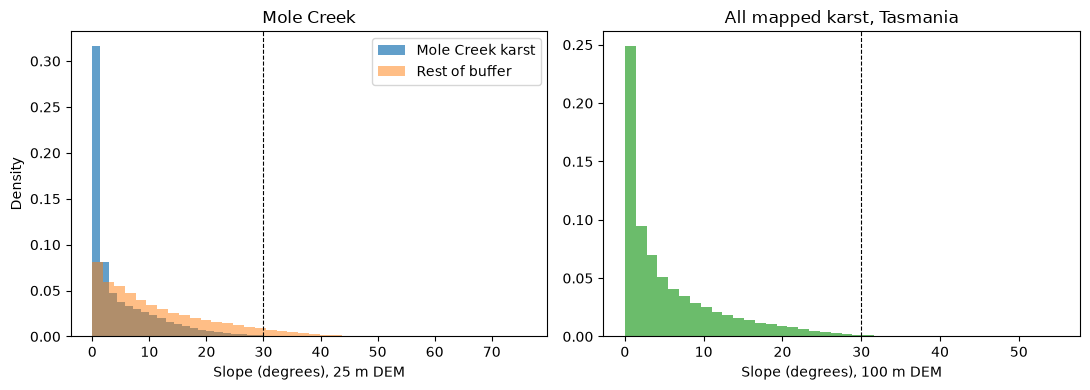

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(on_karst, bins=40, alpha=0.7, density=True, label="Mole Creek karst")
ax[0].hist(off_karst, bins=40, alpha=0.5, density=True, label="Rest of buffer")
ax[0].axvline(SLOPE_REF_DEG, color="k", ls="--", lw=0.8)
ax[0].set_xlabel("Slope (degrees), 25 m DEM"); ax[0].set_ylabel("Density"); ax[0].legend(); ax[0].set_title("Mole Creek")
ax[1].hist(sk, bins=40, alpha=0.7, density=True, color="tab:green")
ax[1].axvline(SLOPE_REF_DEG, color="k", ls="--", lw=0.8)
ax[1].set_xlabel("Slope (degrees), 100 m DEM"); ax[1].set_title("All mapped karst, Tasmania")
plt.tight_layout(); plt.show()

## Results

**Mole Creek karst is gentle.** The median slope is 1.9 degrees and the 90th percentile 14 degrees, against 8.6 and 26 degrees for the rest of the buffer. Within the karst, slope and intrinsic vulnerability are moderately correlated (r = 0.42): the steeper karst cells tend to be the more karstified, exposed ones.

**The effect on the index is modest and does not change the answer at Mole Creek.** Either direction correlates with the frozen risk at r = 0.88 to 0.90 over the karst, and the order of the three Mole Creek areas is the same in both variants (Chudleigh Hill, then Mole Creek, then Meander - Western Creek). Absolute risk falls under both variants (the multiplier is at most 1), so only the pattern and the order are comparable.

**Statewide the effect is also modest.** The rank correlation across named areas is 0.95 (steeper = higher risk) and 0.97 (steeper = lower risk), but the top five reshuffle: for example Doctors Rocks moves to second when steeper means higher. Statewide the correlation between slope and baseline risk is slightly negative (r = -0.25), the opposite sign to Mole Creek, which shows that slope relates to the other layers differently in different places.

**Caveats:**
- **Direction.** The two variants point opposite ways and the data cannot choose between them. There is no ground truth to separate them, and the literature does not settle the sign.
- **Resolution.** A 100 m DEM gives lower slopes than a 25 m DEM (4.3 against 4.9 degrees on the Mole Creek karst), so the statewide slope layer understates steepness.
- **Reference slope.** The 30 degree reference is a judgement. Only 0.5% of mapped karst cells exceed it.

**Recommendation:** keep slope out of the frozen index and report it as a sensitivity result. Adding it would introduce a term whose sign we cannot justify from our own evidence.